<a href="https://colab.research.google.com/github/Karimzakyy/KarimZaky-55-1510/blob/main/Lab%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/heart.csv')
print("Shape:", df.shape)
df.head()


Mounted at /content/drive
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
df.info()
df.describe()
print("Missing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['target'].value_counts())
# 0 = No heart disease, 1 = Heart disease


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
Missing values: 0

Class distribution:
target
1    165
0    138
Name: count, dtype: int64


In [10]:
X = df.drop('target', axis=1)   # 13 features
y = df['target']                 # 0 or 1

print("Features shape:", X.shape)
print("Labels shape:  ", y.shape)


Features shape: (303, 13)
Labels shape:   (303,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=101
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)


Train size: (272, 13)
Test size:  (31, 13)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit ONLY on training data → then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # NO fit here — avoid data leakage

print("Scaling done. Mean of train features (should be ≈0):", X_train_scaled.mean().round(4))


Scaling done. Mean of train features (should be ≈0): 0.0


In [13]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB because all features are continuous numbers
# It models each feature as a Gaussian (bell curve) distribution per class
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Naïve Bayes model trained!")
print("Classes:", nb_model.classes_)
print("Class prior probabilities:", nb_model.class_prior_.round(4))
# Prior = general probability of each class before looking at features
# P(no disease) and P(heart disease) in the training data


Naïve Bayes model trained!
Classes: [0 1]
Class prior probabilities: [0.4522 0.5478]


In [15]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, accuracy_score)

y_pred = nb_model.predict(X_test_scaled)

# Confusion Matrix Array
print("=== Confusion Matrix (Array) ===")
print(confusion_matrix(y_test, y_pred))


=== Confusion Matrix (Array) ===
[[13  2]
 [ 2 14]]


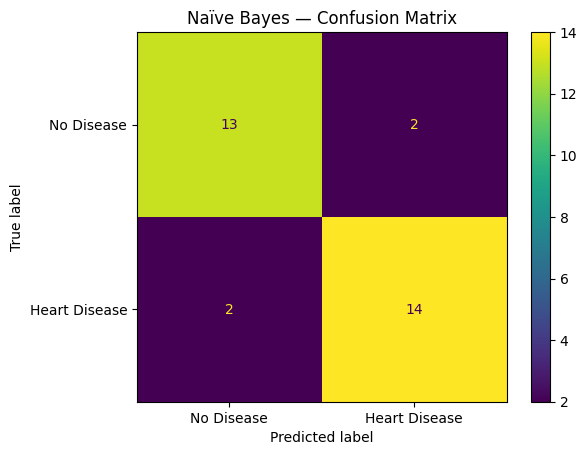

In [16]:
# Confusion Matrix Plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['No Disease', 'Heart Disease'])
plt.title("Naïve Bayes — Confusion Matrix")
plt.show()


In [17]:
# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Heart Disease']))

print("Overall Accuracy:", accuracy_score(y_test, y_pred).round(4))


=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.87      0.87      0.87        15
Heart Disease       0.88      0.88      0.88        16

     accuracy                           0.87        31
    macro avg       0.87      0.87      0.87        31
 weighted avg       0.87      0.87      0.87        31



AttributeError: 'float' object has no attribute 'round'

In [18]:

# Patient features
patient = [[48.0,   # age
             0.0,   # sex
             2.0,   # cp (chest pain type)
           130.0,   # trestbps (resting blood pressure)
           275.0,   # chol (cholesterol)
             0.0,   # fbs (fasting blood sugar)
             1.0,   # restecg
           139.0,   # thalach (max heart rate)
             0.0,   # exang (exercise induced angina)
             0.2,   # oldpeak
             2.0,   # slope
             0.0,   # ca
             2.0]]  # thal

# IMPORTANT: scale the patient data with the SAME scaler
patient_scaled = scaler.transform(patient)

# Prediction (0 or 1)
prediction = nb_model.predict(patient_scaled)

# Probability of each class
probability = nb_model.predict_proba(patient_scaled)

print("=== New Patient Prediction ===")
print(f"Prediction: {prediction[0]} → {'❤️  HEART DISEASE DETECTED' if prediction[0]==1 else '✅ No Heart Disease'}")
print(f"\nModel confidence:")
print(f"  P(No Disease)    = {probability[0][0]*100:.1f}%")
print(f"  P(Heart Disease) = {probability[0][1]*100:.1f}%")

if probability[0][1] > 0.5:
    print(f"\nThe model is {probability[0][1]*100:.1f}% sure this patient HAS heart disease.")
else:
    print(f"\nThe model is {probability[0][0]*100:.1f}% sure this patient does NOT have heart disease.")


=== New Patient Prediction ===
Prediction: 1 → ❤️  HEART DISEASE DETECTED

Model confidence:
  P(No Disease)    = 0.1%
  P(Heart Disease) = 99.9%

The model is 99.9% sure this patient HAS heart disease.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
